Upload your 6 CSV files now.


Saving subject-1.csv to subject-1.csv
Saving subject-2.csv to subject-2.csv
Saving subject-3.csv to subject-3.csv
Saving subject-4.csv to subject-4.csv
Saving subject-5.csv to subject-5.csv
Saving subject-6.csv to subject-6.csv
Files uploaded successfully.


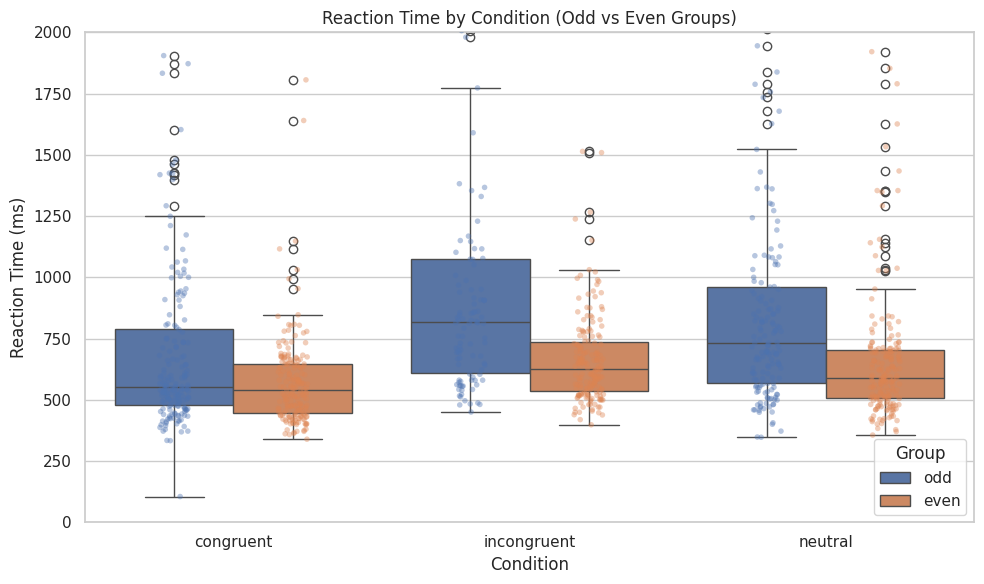

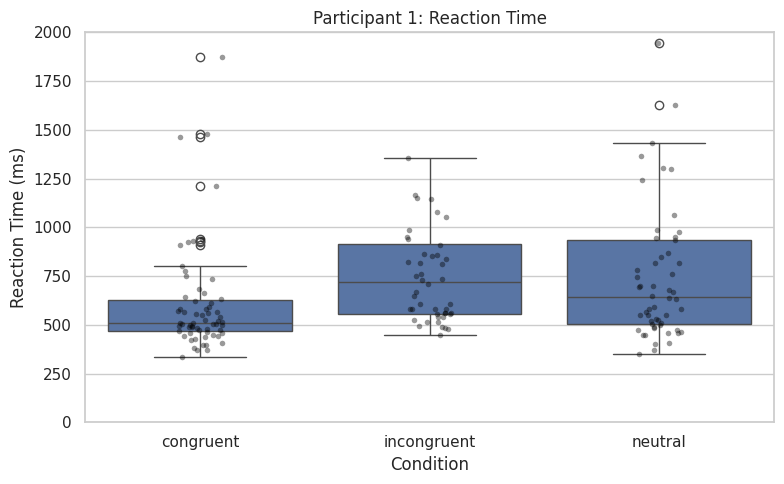

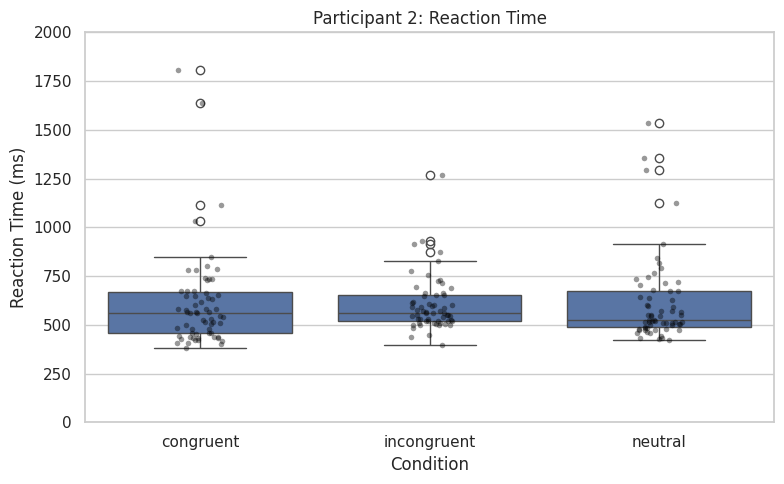

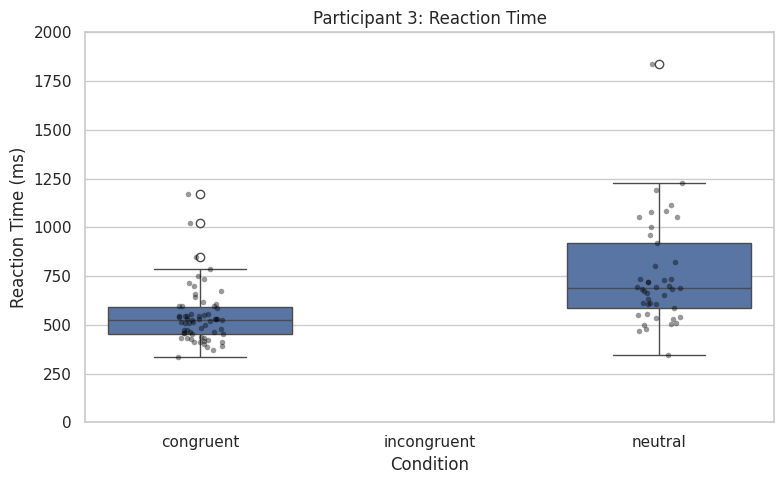

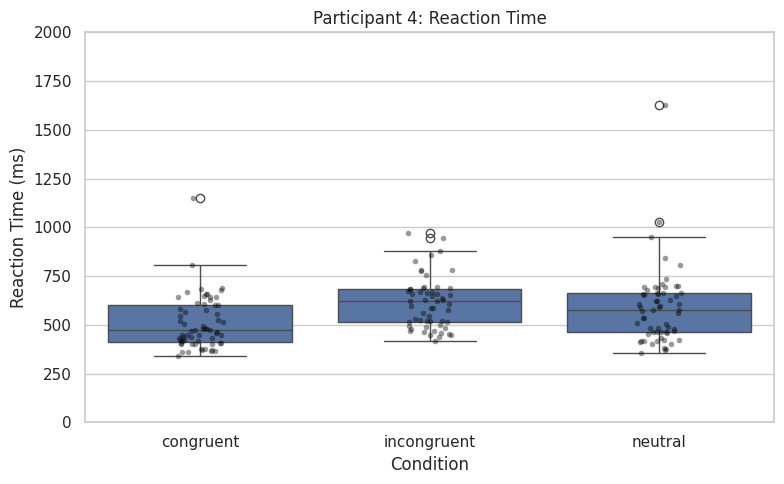

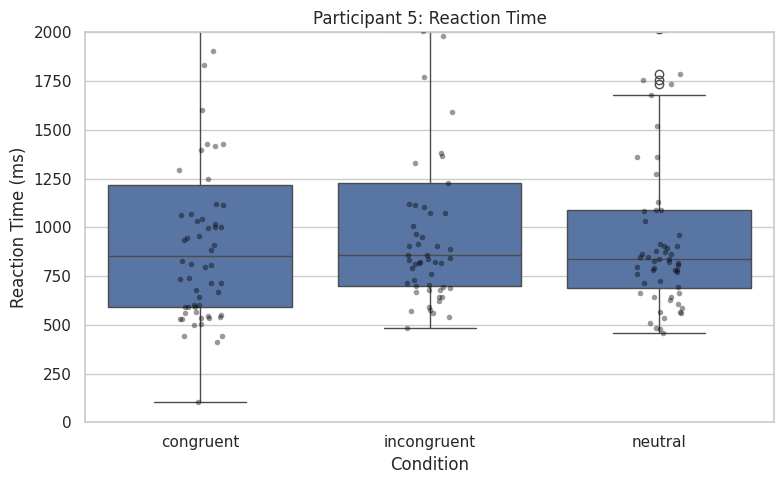

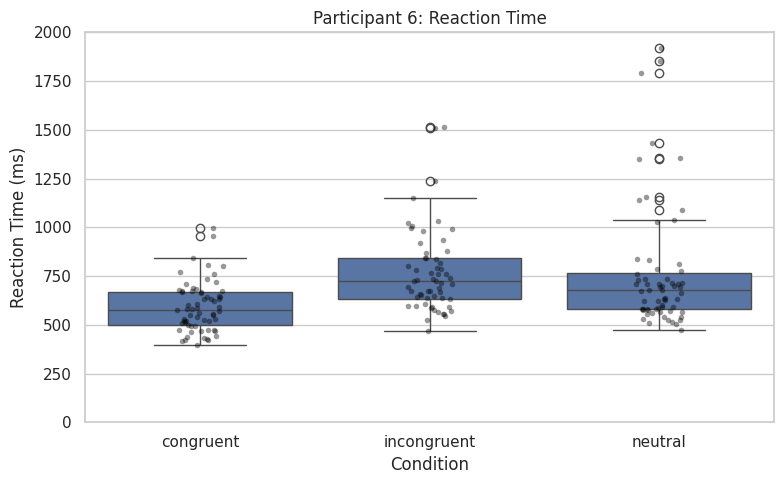

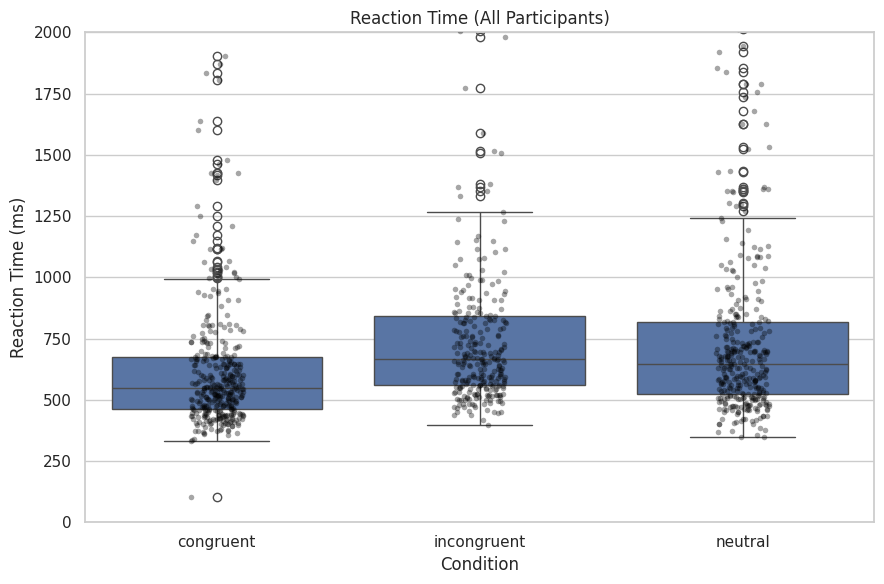

Analysis complete. Plots saved in:
/content/numerical-stroop-task/results


In [1]:
# Numerical Stroop Task Analysis in Python
# Colab version: uploads CSV files manually and saves plots automatically

from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
import os

sns.set(style="whitegrid")

# -----------------------------
# Create folders
# -----------------------------
project_root = Path("/content/numerical-stroop-task")
data_dir = project_root / "data"
results_dir = project_root / "results"

individual_dir = results_dir / "individual"
group_dir = results_dir / "group_comparison"
all_dir = results_dir / "all_participants"

data_dir.mkdir(parents=True, exist_ok=True)
individual_dir.mkdir(parents=True, exist_ok=True)
group_dir.mkdir(parents=True, exist_ok=True)
all_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Upload CSV files
# -----------------------------
print("Upload your 6 CSV files now.")
uploaded = files.upload()

for filename in uploaded.keys():
    with open(data_dir / filename, "wb") as f:
        f.write(uploaded[filename])

print("Files uploaded successfully.")

# -----------------------------
# File list
# -----------------------------
files_list = sorted([f.name for f in data_dir.glob("*.csv")])

condition_map = {
    "c": "congruent",
    "i": "incongruent",
    "n": "neutral"
}

condition_order = ["congruent", "incongruent", "neutral"]

# -----------------------------
# Load and preprocess data
# -----------------------------
all_dfs = []

for i, file_name in enumerate(files_list, start=1):
    file_path = data_dir / file_name
    df = pd.read_csv(file_path)

    df["participant"] = i
    df["group"] = "odd" if i % 2 == 1 else "even"

    all_dfs.append(df)

all_data = pd.concat(all_dfs, ignore_index=True)

# Keep only correct responses
all_data = all_data[all_data["correct"] == 1].copy()

# Convert condition labels
all_data["condition"] = all_data["condition"].map(condition_map)
all_data["condition"] = pd.Categorical(
    all_data["condition"],
    categories=condition_order,
    ordered=True
)

# -----------------------------
# 1. Group Analysis (Odd vs Even)
# -----------------------------
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=all_data,
    x="condition",
    y="response_time_key_response",
    hue="group",
    order=condition_order
)

sns.stripplot(
    data=all_data,
    x="condition",
    y="response_time_key_response",
    hue="group",
    dodge=True,
    alpha=0.4,
    size=4,
    order=condition_order
)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Group", loc="best")

plt.title("Reaction Time by Condition (Odd vs Even Groups)")
plt.xlabel("Condition")
plt.ylabel("Reaction Time (ms)")
plt.ylim(0, 2000)
plt.tight_layout()
plt.savefig(group_dir / "group_odd_even_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# -----------------------------
# 2. Individual Participant Analysis
# -----------------------------
for p, file_name in enumerate(files_list, start=1):
    file_path = data_dir / file_name
    stroop_data = pd.read_csv(file_path)

    stroop_data = stroop_data[stroop_data["correct"] == 1].copy()
    stroop_data["condition"] = stroop_data["condition"].map(condition_map)
    stroop_data["condition"] = pd.Categorical(
        stroop_data["condition"],
        categories=condition_order,
        ordered=True
    )

    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=stroop_data,
        x="condition",
        y="response_time_key_response",
        order=condition_order
    )

    sns.stripplot(
        data=stroop_data,
        x="condition",
        y="response_time_key_response",
        color="black",
        alpha=0.4,
        size=4,
        order=condition_order
    )

    plt.title(f"Participant {p}: Reaction Time")
    plt.xlabel("Condition")
    plt.ylabel("Reaction Time (ms)")
    plt.ylim(0, 2000)
    plt.tight_layout()
    plt.savefig(individual_dir / f"participant_{p}_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

# -----------------------------
# 3. Combined Analysis (All Participants)
# -----------------------------
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=all_data,
    x="condition",
    y="response_time_key_response",
    order=condition_order
)

sns.stripplot(
    data=all_data,
    x="condition",
    y="response_time_key_response",
    color="black",
    alpha=0.35,
    size=4,
    order=condition_order
)

plt.title("Reaction Time (All Participants)")
plt.xlabel("Condition")
plt.ylabel("Reaction Time (ms)")
plt.ylim(0, 2000)
plt.tight_layout()
plt.savefig(all_dir / "all_participants_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Analysis complete. Plots saved in:")
print(results_dir)